# FTLA: Quotient Space of Sensor Measurements

**Vibe-coding assignment** (graded on completion). A connected network of sensors records a measurement at each node. All sensors may share the same unknown calibration offset: adding one number to every reading changes the baseline but not the relative pattern across the network.

Random seed: **2030**. Node positions are generated once from that seed and reused in every network plot.

Libraries: **NumPy**, **Matplotlib**, **NetworkX**.


## Setup and goal

Let \(n\) be the number of sensors and let
\[
\mathbf{x} = (x_0,x_1,\ldots,x_{n-1})\in\mathbb{R}^n
\]
record one measurement at each node. Write \(\mathbf{1}=(1,1,\ldots,1)\) for the all-ones vector and
\[
U = \operatorname{span}\{\mathbf{1}\}
= \{ c\mathbf{1}: c\in\mathbb{R} \}
\subset \mathbb{R}^n.
\]
Two measurement vectors are equivalent when they differ by a uniform shift:
\[
\mathbf{x}\sim\mathbf{y}
\quad\Longleftrightarrow\quad
\mathbf{y}-\mathbf{x}\in U
\quad\Longleftrightarrow\quad
\mathbf{y}=\mathbf{x}+c\mathbf{1}
\text{ for some }c\in\mathbb{R}.
\]
The quotient space
\[
Q = \mathbb{R}^n / U
= \{ [\mathbf{x}]: \mathbf{x}\in\mathbb{R}^n \},
\qquad
[\mathbf{x}] = \mathbf{x}+U = \{ \mathbf{x}+c\mathbf{1}: c\in\mathbb{R} \},
\]
remembers the **relative pattern** of measurements and forgets the **shared baseline**.

For each edge \((i,j)\) we display the difference
\[
d_{ij}(\mathbf{x}) = x_j - x_i.
\]
These differences are constant on each equivalence class, because
\[
d_{ij}(\mathbf{x}+c\mathbf{1})
= (x_j+c)-(x_i+c)
= x_j-x_i
= d_{ij}(\mathbf{x}).
\]

**Goals**

1. Build and visualize equivalence classes.
2. Choose a useful representative of each class.
3. Test addition and scalar multiplication in the quotient.
4. Determine \(\dim Q\).


## Imports and random seed


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import networkx as nx

SEED = 2030
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.figsize": (9, 4.2),
    "font.size": 11,
    "axes.grid": False,
    "figure.constrained_layout.use": True,
})

print("random seed:", SEED)
print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__, "| networkx", nx.__version__)


random seed: 2030
numpy 2.1.3 | matplotlib 3.10.0 | networkx 3.4.2


---
# Work Section 1: Build and Visualize Equivalence Classes

## A. Create the network and its measurements

We build a connected 7-node sensor graph: a ring, plus skip-one chords so every node has a few neighbors. Positions are sampled **once** from seed 2030 and stored in `POS`; every later plot reuses that same dictionary.


n = 7
connected: True | nodes: 7 | edges: 12
measurements x =
[-0.9058  1.4028 -1.4127  1.5161  1.9834 -0.489   1.1595]


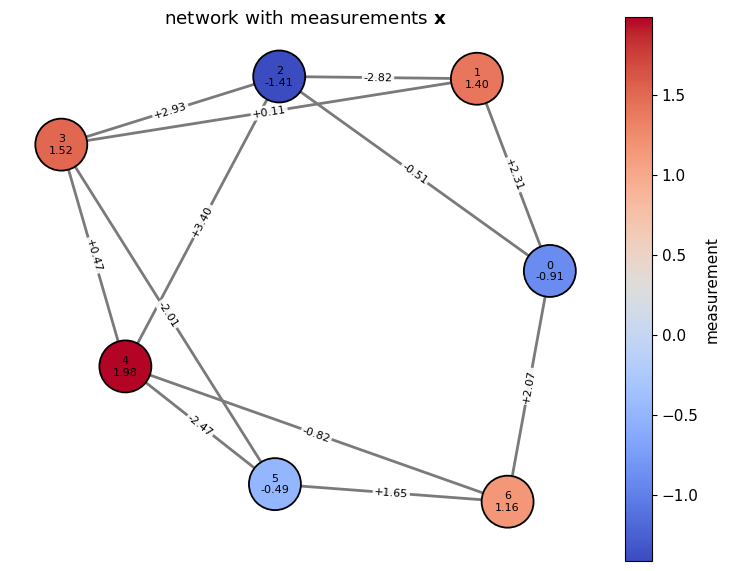


edge differences d_ij = x_j - x_i
  edge (0,1): +2.3086
  edge (0,2): -0.5070
  edge (0,6): +2.0653
  edge (1,2): -2.8155
  edge (1,3): +0.1133
  edge (2,3): +2.9288
  edge (2,4): +3.3962
  edge (3,4): +0.4673
  edge (3,5): -2.0051
  edge (4,5): -2.4724
  edge (4,6): -0.8239
  edge (5,6): +1.6485


In [2]:
n = 7
nodes = list(range(n))
ones = np.ones(n)

# Ring plus skip-one chords: connected, small, easy to read.
edges = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 0),
    (0, 2), (2, 4), (4, 6), (1, 3), (3, 5),
]

G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
assert nx.is_connected(G), "the sensor network must be connected"

# Fixed layout: a slightly jittered circle, generated once.
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
radii = 1.0 + 0.10 * rng.normal(size=n)
POS = {i: (float(radii[i] * np.cos(theta[i])),
           float(radii[i] * np.sin(theta[i])))
       for i in nodes}

# One random real measurement per node.
x = rng.normal(size=n)

print("n =", n)
print("connected:", nx.is_connected(G), "| nodes:", G.number_of_nodes(), "| edges:", G.number_of_edges())
print("measurements x =")
np.set_printoptions(precision=4, suppress=True)
print(x)


def edge_differences(values, graph=G):
    # d_ij = x_j - x_i for each undirected edge (i, j) with i < j
    return {(i, j): values[j] - values[i] for i, j in graph.edges()}


def draw_measurement_network(ax, values, title, vmin, vmax, cmap="coolwarm"):
    # Draw G at the global positions POS. Node color/label = measurement; edge label = x_j - x_i.
    values = np.asarray(values, dtype=float)
    nx.draw_networkx_edges(G, POS, ax=ax, width=2.0, edge_color="#7a7a7a")
    nx.draw_networkx_nodes(
        G, POS, ax=ax,
        node_color=values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        node_size=1400,
        edgecolors="black",
        linewidths=1.3,
    )
    node_labels = {i: f"{i}\n{values[i]:.2f}" for i in G.nodes()}
    nx.draw_networkx_labels(G, POS, labels=node_labels, ax=ax, font_size=8)
    edge_labels = {(i, j): f"{values[j] - values[i]:+.2f}" for i, j in G.edges()}
    nx.draw_networkx_edge_labels(
        G, POS, edge_labels=edge_labels, ax=ax, font_size=8,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9),
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


def add_colorbar(fig, ax, vmin, vmax, cmap="coolwarm", label="measurement"):
    sm = cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label=label)


vmin0, vmax0 = float(x.min()), float(x.max())
fig, ax = plt.subplots(figsize=(7.2, 6.2))
draw_measurement_network(ax, x, r"network with measurements $\mathbf{x}$", vmin0, vmax0)
add_colorbar(fig, ax, vmin0, vmax0)
plt.show()

print()
print("edge differences d_ij = x_j - x_i")
for (i, j), d in sorted(edge_differences(x).items()):
    print(f"  edge ({i},{j}): {d:+.4f}")


Choose a random scalar \(c\) and form
\[
\mathbf{y} = \mathbf{x} + c\mathbf{1}.
\]
The next figure draws \(\mathbf{x}\) and \(\mathbf{y}\) **side by side, on the same color scale, at the same node positions**. Node measurements (labels and colors) change; every edge difference stays the same.


c = 0.4926
x = [-0.9058  1.4028 -1.4127  1.5161  1.9834 -0.489   1.1595]
y = [-0.4132  1.8954 -0.9201  2.0087  2.476   0.0036  1.6521]
y - x = [0.4926 0.4926 0.4926 0.4926 0.4926 0.4926 0.4926]

      edge     x_j - x_i     y_j - y_i    match
    (0, 1)       +2.3086       +2.3086      yes
    (0, 2)       -0.5070       -0.5070      yes
    (0, 6)       +2.0653       +2.0653      yes
    (1, 2)       -2.8155       -2.8155      yes
    (1, 3)       +0.1133       +0.1133      yes
    (2, 3)       +2.9288       +2.9288      yes
    (2, 4)       +3.3962       +3.3962      yes
    (3, 4)       +0.4673       +0.4673      yes
    (3, 5)       -2.0051       -2.0051      yes
    (4, 5)       -2.4724       -2.4724      yes
    (4, 6)       -0.8239       -0.8239      yes
    (5, 6)       +1.6485       +1.6485      yes

all edge differences identical: True


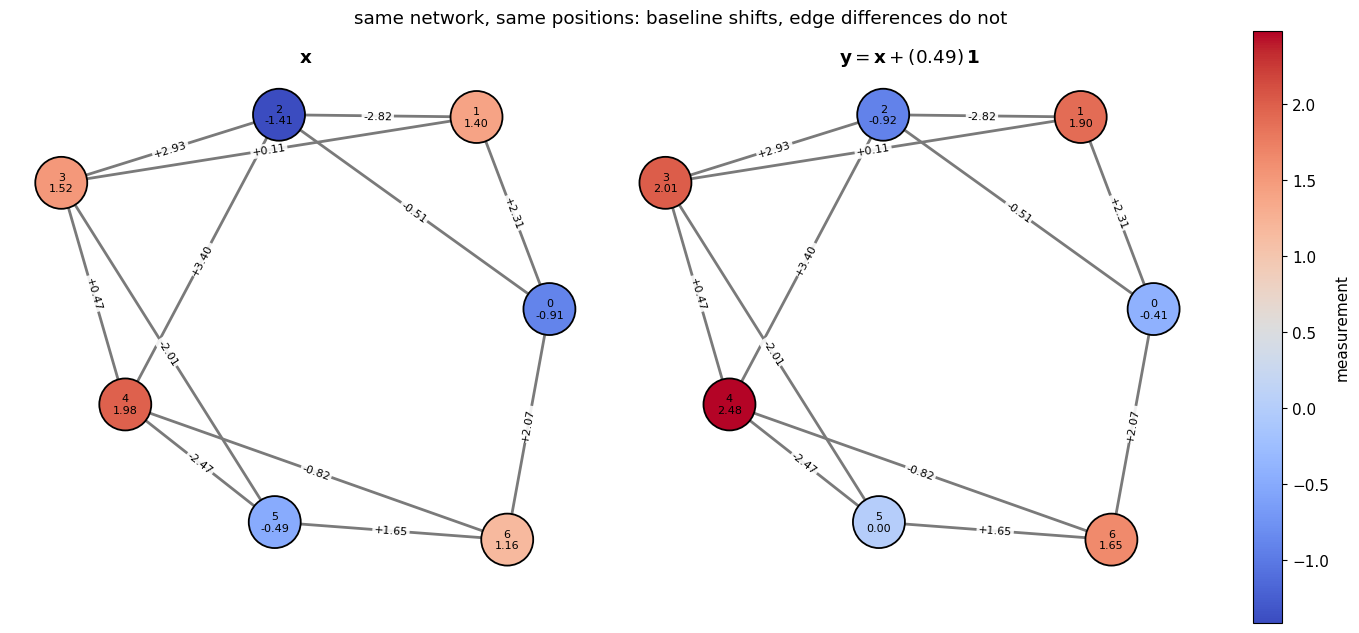

In [3]:
c = float(rng.uniform(-2.5, 2.5))
y = x + c * ones

print(f"c = {c:.4f}")
print("x =", x)
print("y =", y)
print("y - x =", y - x)

d_x = edge_differences(x)
d_y = edge_differences(y)

print()
print(f"{'edge':>10}  {'x_j - x_i':>12}  {'y_j - y_i':>12}  {'match':>7}")
all_match = True
for e in sorted(d_x):
    match = np.isclose(d_x[e], d_y[e], atol=1e-12)
    all_match = all_match and bool(match)
    print(f"{str(e):>10}  {d_x[e]:+12.4f}  {d_y[e]:+12.4f}  {'yes' if match else 'NO':>7}")
print()
print("all edge differences identical:", all_match)

# Shared color scale so the baseline shift is visible in color as well as in the labels.
vmin = float(min(x.min(), y.min()))
vmax = float(max(x.max(), y.max()))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0))
draw_measurement_network(axes[0], x, r"$\mathbf{x}$", vmin, vmax)
draw_measurement_network(axes[1], y, rf"$\mathbf{{y}}=\mathbf{{x}}+({c:.2f})\,\mathbf{{1}}$", vmin, vmax)
add_colorbar(fig, axes, vmin, vmax)
fig.suptitle("same network, same positions: baseline shifts, edge differences do not", y=1.03)
plt.show()


### Why the node values change but the edge differences do not

Each coordinate of \(\mathbf{y}\) is the corresponding coordinate of \(\mathbf{x}\) plus the **same** number \(c\). That is a change of baseline: every sensor is recalibrated by the same offset, so the colored labels all move.

On an edge \((i,j)\),
\[
y_j - y_i = (x_j + c) - (x_i + c) = x_j - x_i.
\]
The two \(c\)'s cancel. Differences are invariant under uniform shifts, so \(\mathbf{x}\) and \(\mathbf{y}\) encode the same relative pattern and represent the **same** point of \(Q\). In the pictures, the numbers on the edges are identical even though the numbers on the nodes are not.


## B. Test the equivalence relation

### \(U\) is a subspace of \(\mathbb{R}^n\)

A nonempty subset of a known vector space is a subspace if it contains \(\mathbf{0}\) and is closed under addition and scalar multiplication. We check all three, both algebraically and on random samples from \(U\).


In [4]:
def in_U(v, tol=1e-12):
    # True iff v is (numerically) a constant vector, i.e. v in span{1}.
    v = np.asarray(v, dtype=float)
    return bool(np.allclose(v, v[0] * np.ones_like(v), atol=tol, rtol=tol))


def report(name, ok):
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
    return ok


print("U = span{1}  subset  R^n")
results = []

# Zero vector: 0 = 0 * 1.
results.append(report("0 is in U", in_U(np.zeros(n)) and np.allclose(0.0 * ones, 0.0)))

# Closed under addition: c1*1 + c2*1 = (c1+c2)*1.
n_add = 0
trials = 100
for _ in range(trials):
    u1 = rng.normal() * ones
    u2 = rng.normal() * ones
    n_add += int(in_U(u1) and in_U(u2) and in_U(u1 + u2)
                 and np.allclose(u1 + u2, (u1[0] + u2[0]) * ones))
results.append(report(f"closed under addition ({n_add}/{trials})", n_add == trials))

# Closed under scalar multiplication: lam * (c*1) = (lam c)*1.
n_scale = 0
for _ in range(trials):
    u = rng.normal() * ones
    lam = rng.normal()
    n_scale += int(in_U(u) and in_U(lam * u)
                   and np.allclose(lam * u, (lam * u[0]) * ones))
results.append(report(f"closed under scalar multiplication ({n_scale}/{trials})", n_scale == trials))

print()
print("U is a subspace:" , "PASS" if all(results) else "FAIL")
print("algebra: U is the span of one nonzero vector, hence a 1-dimensional subspace.")


U = span{1}  subset  R^n
  [PASS] 0 is in U
  [PASS] closed under addition (100/100)
  [PASS] closed under scalar multiplication (100/100)

U is a subspace: PASS
algebra: U is the span of one nonzero vector, hence a 1-dimensional subspace.


### The function `equivalent_measurements`

\(\mathbf{x}\sim\mathbf{y}\) if and only if every entry of \(\mathbf{y}-\mathbf{x}\) is the same number (the shared offset). The test below checks that, up to a numerical tolerance.


In [5]:
def equivalent_measurements(x, y, tol=1e-10):
    # True iff y - x is approximately a constant vector.
    diff = np.asarray(y, dtype=float) - np.asarray(x, dtype=float)
    if diff.size == 0:
        return True
    return bool(np.allclose(diff, diff.flat[0], atol=tol, rtol=tol))


def verdict(ok):
    return "PASS" if ok else "FAIL"


# --- 100 true pairs y = x + c 1 -------------------------------------------
n_true = 0
true_trials = 100
for _ in range(true_trials):
    x_t = rng.normal(size=n)
    c_t = rng.normal()
    y_t = x_t + c_t * ones
    n_true += int(equivalent_measurements(x_t, y_t))
print(f"[{verdict(n_true == true_trials)}] 100 pairs y = x + c*1 recognized as equivalent  "
      f"({n_true}/{true_trials})")

# --- false examples: change one or two coordinates ------------------------
print()
print("false examples (only one or two node measurements changed):")
x0 = rng.normal(size=n)

false_cases = []

y_one = x0.copy()
y_one[3] += 1.7
false_cases.append(("change one node (index 3)", x0, y_one, False))

y_two = x0.copy()
y_two[1] -= 0.8
y_two[5] += 1.1
false_cases.append(("change two nodes (indices 1 and 5)", x0, y_two, False))

y_almost = x0 + 0.4 * ones
y_almost[2] += 0.25  # uniform shift, then one extra bump
false_cases.append(("uniform shift PLUS one extra bump", x0, y_almost, False))

y_real = x0 + (-1.3) * ones
false_cases.append(("control: genuine uniform shift", x0, y_real, True))

false_ok = True
for name, a, b, should_be_eq in false_cases:
    got = equivalent_measurements(a, b)
    ok = (got == should_be_eq)
    false_ok = false_ok and ok
    print(f"  [{verdict(ok)}] {name:40s}  equivalent={got}  (expected {should_be_eq})")
    print(f"           y-x = {b - a}")

print(f"[{verdict(false_ok)}] false-example battery")

# --- reflexivity, symmetry, transitivity ----------------------------------
print()
print("equivalence-relation axioms on random examples:")

n_ref = n_sym = n_trans = 0
axiom_trials = 100
for _ in range(axiom_trials):
    a = rng.normal(size=n)
    # reflexivity: x ~ x
    n_ref += int(equivalent_measurements(a, a))

    c1, c2 = rng.normal(), rng.normal()
    b = a + c1 * ones
    d = b + c2 * ones  # so a ~ b ~ d, hence a ~ d
    n_sym += int(equivalent_measurements(a, b) and equivalent_measurements(b, a))
    n_trans += int(
        equivalent_measurements(a, b)
        and equivalent_measurements(b, d)
        and equivalent_measurements(a, d)
    )

print(f"  [{verdict(n_ref == axiom_trials)}] reflexive   ({n_ref}/{axiom_trials})")
print(f"  [{verdict(n_sym == axiom_trials)}] symmetric   ({n_sym}/{axiom_trials})")
print(f"  [{verdict(n_trans == axiom_trials)}] transitive  ({n_trans}/{axiom_trials})")

# One extra transitivity check with three unrelated-looking representatives of the same class.
base = rng.normal(size=n)
p = base + 2.0 * ones
q = base - 0.5 * ones
r = base + 4.1 * ones
trans_extra = (
    equivalent_measurements(p, q)
    and equivalent_measurements(q, r)
    and equivalent_measurements(p, r)
)
print(f"  [{verdict(trans_extra)}] transitivity on three explicit representatives of one class")


[PASS] 100 pairs y = x + c*1 recognized as equivalent  (100/100)

false examples (only one or two node measurements changed):
  [PASS] change one node (index 3)                 equivalent=False  (expected False)
           y-x = [0.  0.  0.  1.7 0.  0.  0. ]
  [PASS] change two nodes (indices 1 and 5)        equivalent=False  (expected False)
           y-x = [ 0.  -0.8  0.   0.   0.   1.1  0. ]
  [PASS] uniform shift PLUS one extra bump         equivalent=False  (expected False)
           y-x = [0.4  0.4  0.65 0.4  0.4  0.4  0.4 ]
  [PASS] control: genuine uniform shift            equivalent=True  (expected True)
           y-x = [-1.3 -1.3 -1.3 -1.3 -1.3 -1.3 -1.3]
[PASS] false-example battery

equivalence-relation axioms on random examples:
  [PASS] reflexive   (100/100)
  [PASS] symmetric   (100/100)
  [PASS] transitive  (100/100)
  [PASS] transitivity on three explicit representatives of one class


### Why a shared-baseline change stays inside the same quotient element

By definition \([\mathbf{x}]=\mathbf{x}+U=\{\mathbf{x}+c\mathbf{1}:c\in\mathbb{R}\}\). Replacing \(\mathbf{x}\) by \(\mathbf{x}+c\mathbf{1}\) does not leave this set: it is another listing of the same affine line, parallel to \(\mathbf{1}\), through \(\mathbf{x}\). Equivalence classes of \(\sim\) **are** the cosets of \(U\), so a uniform calibration offset moves us to another representative of the **same** point of \(Q\). What \(Q\) can still see is anything constant along that line — in particular, every edge difference \(x_j-x_i\).


A picture of the same fact in the first three coordinates: points \(\mathbf{x}+c\mathbf{1}\) trace a line parallel to \((1,1,1)\). The whole line is a single element of \(Q\).


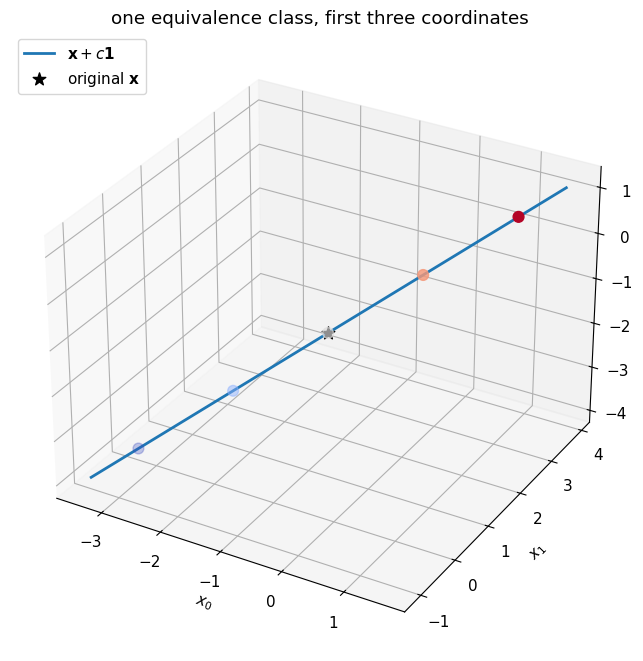

In [6]:
fig = plt.figure(figsize=(8.5, 6.5))
ax = fig.add_subplot(111, projection="3d")

cs = np.linspace(-2.5, 2.5, 80)
line = x[:3] + cs[:, None]
ax.plot(line[:, 0], line[:, 1], line[:, 2], color="C0", lw=2, label=r"$\mathbf{x}+c\mathbf{1}$")

sample_c = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
pts = x[:3] + sample_c[:, None]
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=sample_c, cmap="coolwarm", s=60, depthshade=True)
ax.scatter(*x[:3], color="k", s=90, marker="*", label=r"original $\mathbf{x}$")

ax.set_xlabel(r"$x_0$")
ax.set_ylabel(r"$x_1$")
ax.set_zlabel(r"$x_2$")
ax.set_title("one equivalence class, first three coordinates")
ax.legend(loc="upper left")
plt.show()


---
# Work Section 2: Represent and Compute with Quotient Elements

## A. Choose a reference-node representative

Use node \(0\) as a reference and define the map
\[
R(\mathbf{x}) = \mathbf{x} - x_0\,\mathbf{1}.
\]
Then \(R(\mathbf{x})\sim\mathbf{x}\) (we subtracted an element of \(U\)) and the first entry of \(R(\mathbf{x})\) is zero:
\[
R(\mathbf{x})_0 = x_0 - x_0 = 0.
\]
So \(R\) picks, from each class, the unique representative that treats sensor \(0\) as the zero of the scale.


In [7]:
def R(vec):
    # Reference-node representative: subtract x_0 from every coordinate.
    vec = np.asarray(vec, dtype=float)
    return vec - vec[0] * np.ones_like(vec)


print("original x      =", x)
print("R(x)            =", R(x))
print("R(x)[0] == 0    =", np.isclose(R(x)[0], 0.0))
print("x ~ R(x)        =", equivalent_measurements(x, R(x)))

# Several equivalent vectors, one class.
shifts = np.array([0.0, -1.7, 0.8, 2.4, -3.1])
equivalents = [x + s * ones for s in shifts]

print()
print("equivalent inputs x + c*1 and their images under R:")
print(f"{'c':>8}  {'input[0]':>10}  {'R(input) matches R(x)':>22}")
all_same = True
images = []
for s, vec in zip(shifts, equivalents):
    image = R(vec)
    images.append(image)
    same = np.allclose(image, R(x), atol=1e-12)
    all_same = all_same and bool(same)
    print(f"{s:+8.2f}  {vec[0]:+10.4f}  {str(same):>22}")
    print(f"          input = {vec}")
    print(f"          R     = {image}")

print()
print(f"[{verdict(all_same)}] R sends every equivalent vector to the same representative")
print("common representative R(x) =", R(x))


original x      = [-0.9058  1.4028 -1.4127  1.5161  1.9834 -0.489   1.1595]
R(x)            = [ 0.      2.3086 -0.507   2.4219  2.8892  0.4168  2.0653]
R(x)[0] == 0    = True
x ~ R(x)        = True

equivalent inputs x + c*1 and their images under R:
       c    input[0]   R(input) matches R(x)
   +0.00     -0.9058                    True
          input = [-0.9058  1.4028 -1.4127  1.5161  1.9834 -0.489   1.1595]
          R     = [ 0.      2.3086 -0.507   2.4219  2.8892  0.4168  2.0653]
   -1.70     -2.6058                    True
          input = [-2.6058 -0.2972 -3.1127 -0.1839  0.2834 -2.189  -0.5405]
          R     = [ 0.      2.3086 -0.507   2.4219  2.8892  0.4168  2.0653]
   +0.80     -0.1058                    True
          input = [-0.1058  2.2028 -0.6127  2.3161  2.7834  0.311   1.9595]
          R     = [ 0.      2.3086 -0.507   2.4219  2.8892  0.4168  2.0653]
   +2.40     +1.4942                    True
          input = [1.4942 3.8028 0.9873 3.9161 4.3834 1.911  3.5595]

Plot the five equivalent vectors (different baselines, same pattern) and, underneath, the five images under \(R\) (visually identical, first node equal to \(0\)).


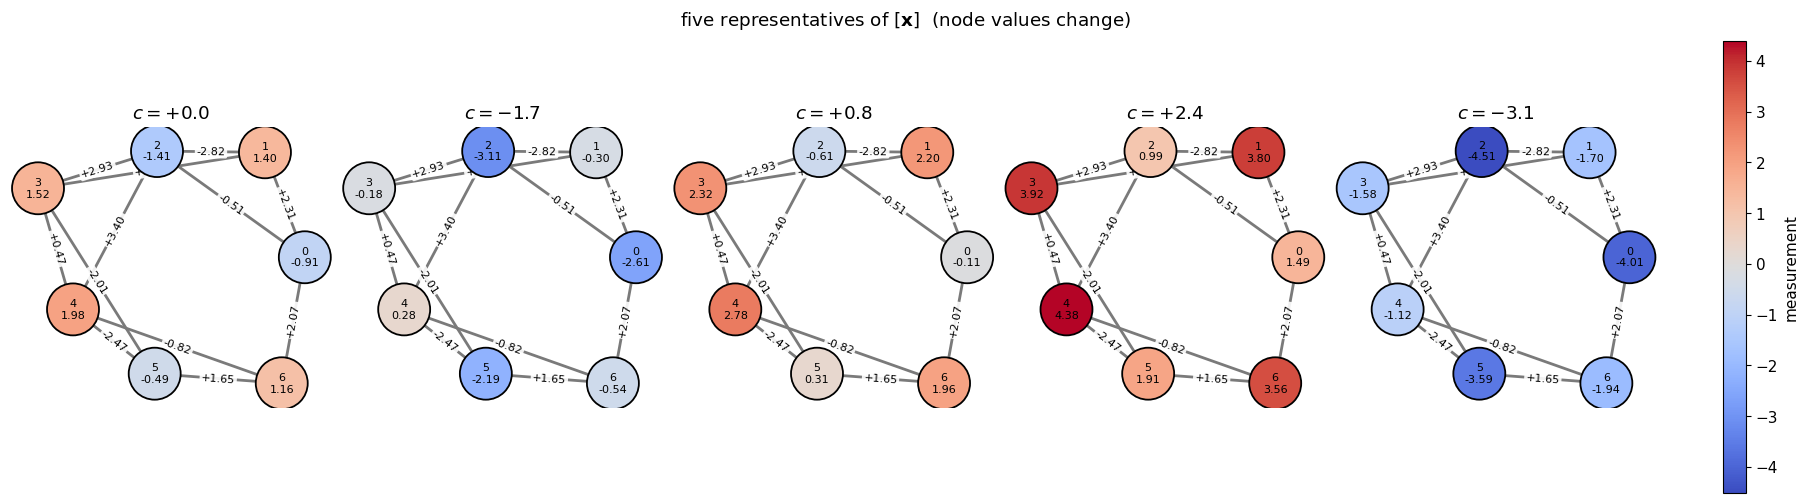

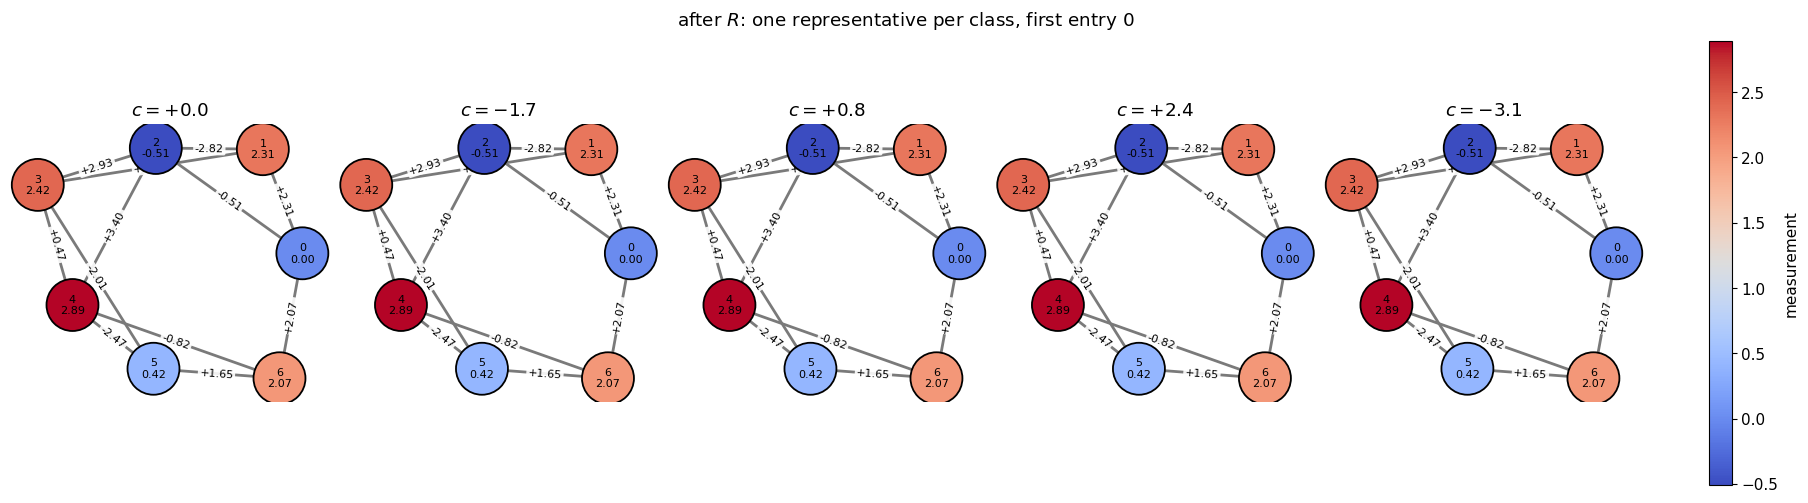

max |R(x+c1) - R(x)| over the five shifts: 7.771561172376096e-16


In [8]:
# Color scale covering all five equivalent vectors, so the baseline drift is visible.
stack = np.stack(equivalents)
vmin_eq, vmax_eq = float(stack.min()), float(stack.max())

fig, axes = plt.subplots(1, 5, figsize=(18, 4.6))
for ax, s, vec in zip(axes, shifts, equivalents):
    draw_measurement_network(ax, vec, rf"$c={s:+.1f}$", vmin_eq, vmax_eq)
fig.suptitle(r"five representatives of $[\mathbf{x}]$  (node values change)", y=1.06)
add_colorbar(fig, axes, vmin_eq, vmax_eq)
plt.show()

rep_stack = np.stack(images)
vmin_r, vmax_r = float(rep_stack.min()), float(rep_stack.max())
# If they really coincide, the color range still has width from the other n-1 nodes.
fig, axes = plt.subplots(1, 5, figsize=(18, 4.6))
for ax, s, image in zip(axes, shifts, images):
    draw_measurement_network(ax, image, rf"$c={s:+.1f}$", vmin_r, vmax_r)
fig.suptitle(r"after $R$: one representative per class, first entry $0$", y=1.06)
add_colorbar(fig, axes, vmin_r, vmax_r)
plt.show()

print("max |R(x+c1) - R(x)| over the five shifts:",
      max(np.max(np.abs(image - R(x))) for image in images))


### Why every class contains **exactly one** vector whose first entry is zero

**Existence.** For any \(\mathbf{x}\), the vector \(R(\mathbf{x})=\mathbf{x}-x_0\mathbf{1}\) lies in \([\mathbf{x}]\) and satisfies \(R(\mathbf{x})_0=0\).

**Uniqueness.** Suppose \(\mathbf{v}\) and \(\mathbf{w}\) both lie in \([\mathbf{x}]\) and both have first entry \(0\). Then \(\mathbf{v}-\mathbf{w}=c\mathbf{1}\) for some \(c\), so
\[
v_0 - w_0 = c.
\]
But \(v_0=w_0=0\), hence \(c=0\) and \(\mathbf{v}=\mathbf{w}\).

Geometrically, the hyperplane \(\{ \mathbf{v}: v_0=0 \}\) is a linear complement of \(U=\operatorname{span}\{\mathbf{1}\}\): it meets each line parallel to \(\mathbf{1}\) exactly once. That is what it means to choose a complete set of representatives.


## B. Test quotient operations and determine the dimension

In \(Q=\mathbb{R}^n/U\) the operations are defined on representatives:
\[
[\mathbf{x}]+[\mathbf{y}] := [\mathbf{x}+\mathbf{y}],
\qquad
\lambda[\mathbf{x}] := [\lambda\mathbf{x}].
\]
These formulas appear to depend on the choice of \(\mathbf{x}\) and \(\mathbf{y}\). They do not, provided we used a subspace (so \(U\) is closed under addition and scaling). Explicitly: if \(\mathbf{x}'=\mathbf{x}+c_1\mathbf{1}\) and \(\mathbf{y}'=\mathbf{y}+c_2\mathbf{1}\), then
\begin{align*}
\mathbf{x}'+\mathbf{y}'
&= \mathbf{x}+\mathbf{y}+(c_1+c_2)\mathbf{1}
\sim \mathbf{x}+\mathbf{y}, \\
\lambda\mathbf{x}'
&= \lambda\mathbf{x}+(\lambda c_1)\mathbf{1}
\sim \lambda\mathbf{x}.
\end{align*}
So
\[
[\mathbf{x}+\mathbf{y}]=[\mathbf{x}'+\mathbf{y}']
\quad\text{and}\quad
[\lambda\mathbf{x}]=[\lambda\mathbf{x}'].
\]


In [9]:
# One explicit tuple with [x]=[x'] and [y]=[y'].
x_vec = rng.normal(size=n)
y_vec = rng.normal(size=n)
c1, c2 = float(rng.normal()), float(rng.normal())
lam = float(rng.normal())
x_alt = x_vec + c1 * ones
y_alt = y_vec + c2 * ones

print("explicit well-definedness check")
print("x  =", x_vec)
print("x' =", x_alt, f"  (c1 = {c1:.4f})")
print("y  =", y_vec)
print("y' =", y_alt, f"  (c2 = {c2:.4f})")
print("λ  =", lam)
print()
print(f"  [{verdict(equivalent_measurements(x_vec, x_alt))}] [x] = [x']")
print(f"  [{verdict(equivalent_measurements(y_vec, y_alt))}] [y] = [y']")
print(f"  [{verdict(equivalent_measurements(x_vec + y_vec, x_alt + y_alt))}] [x+y] = [x'+y']")
print(f"  [{verdict(equivalent_measurements(lam * x_vec, lam * x_alt))}] [λx]  = [λx']")

# Random trials.
n_add_q = n_scale_q = 0
q_trials = 100
for _ in range(q_trials):
    xv = rng.normal(size=n)
    yv = rng.normal(size=n)
    xv2 = xv + rng.normal() * ones
    yv2 = yv + rng.normal() * ones
    lam_t = rng.normal()
    n_add_q += int(equivalent_measurements(xv + yv, xv2 + yv2))
    n_scale_q += int(equivalent_measurements(lam_t * xv, lam_t * xv2))

print()
print(f"[{verdict(n_add_q == q_trials)}] [x+y] = [x'+y'] on {n_add_q}/{q_trials} random trials")
print(f"[{verdict(n_scale_q == q_trials)}] [λx] = [λx']   on {n_scale_q}/{q_trials} random trials")


explicit well-definedness check
x  = [ 0.8727 -1.5811 -1.6468 -0.6333 -1.8244  1.2991 -0.7974]
x' = [3.061  0.6072 0.5415 1.555  0.3639 3.4874 1.3909]   (c1 = 2.1883)
y  = [ 0.6066  1.2545  1.4068 -0.0661 -1.1424  1.331   0.0069]
y' = [-1.0734 -0.4255 -0.2732 -1.7461 -2.8224 -0.349  -1.6731]   (c2 = -1.6800)
λ  = 0.4175136015751077

  [PASS] [x] = [x']
  [PASS] [y] = [y']
  [PASS] [x+y] = [x'+y']
  [PASS] [λx]  = [λx']

[PASS] [x+y] = [x'+y'] on 100/100 random trials
[PASS] [λx] = [λx']   on 100/100 random trials


The random trials succeed because adding (or scaling) two different representatives of the same classes only adds (or scales) extra pieces of \(U\), and \(U\) is a subspace, so those extra pieces remain in \(U\). The coset — the quotient element — does not change. That is exactly the statement that the quotient operations are **well-defined**: they do not depend on which representatives we choose.


### Dimension of \(Q\)

Two viewpoints, same answer \(\dim Q = n-1\).

**Viewpoint 1 (quotient formula).** For a subspace \(U\subset\mathbb{R}^n\),
\[
\dim(\mathbb{R}^n/U) = \dim\mathbb{R}^n - \dim U.
\]
Here \(\dim\mathbb{R}^n=n\) and \(\dim U=1\) (one nonzero generator \(\mathbf{1}\)), so \(\dim Q=n-1\).

**Viewpoint 2 (free measurements after pinning a reference).** The map \(R\) is a linear projection onto the hyperplane \(v_0=0\), along the direction \(\mathbf{1}\). After forcing the first measurement to \(0\), the remaining \(n-1\) coordinates of \(R(\mathbf{x})\) may be chosen freely, and they label the class uniquely. So there are \(n-1\) free parameters.


In [10]:
# Viewpoint 1: dim U = rank of a matrix whose column is 1.
U_mat = ones.reshape(n, 1)
dim_U = int(np.linalg.matrix_rank(U_mat))
dim_Rn = n
dim_Q_formula = dim_Rn - dim_U

print("viewpoint 1: dim(R^n / U) = dim R^n - dim U")
print("  dim R^n =", dim_Rn)
print("  dim U   =", dim_U, "  (rank of [1] =", dim_U, ")")
print("  dim Q   =", dim_Q_formula)

# Viewpoint 2: rank of the linear map R(x) = x - x_0 1 = (I - 1 e0^T) x.
e0 = np.zeros(n)
e0[0] = 1.0
R_mat = np.eye(n) - np.outer(ones, e0)
rank_R = int(np.linalg.matrix_rank(R_mat))
# Nullity: ker R = U.
null_R = n - rank_R

print()
print("viewpoint 2: after setting the first measurement to 0")
print("  matrix of R has shape", R_mat.shape)
print("  rank(R)    =", rank_R, "  (n-1 free coordinates in the image)")
print("  nullity(R) =", null_R, "  (ker R = U)")
print("  R(x)[0] is always", R(rng.normal(size=n))[0])

# The n-1 free coordinates really do parametrize Q: two vectors with the
# same R-image are equivalent, and every (0, a1, ..., a_{n-1}) is an R-image.
param_ok = True
for _ in range(50):
    a = rng.normal(size=n)
    b = rng.normal(size=n)
    # same class iff same representative
    same_class = equivalent_measurements(a, b)
    same_rep = np.allclose(R(a), R(b), atol=1e-12)
    param_ok = param_ok and (same_class == same_rep)

    # every vector with first entry 0 is already a representative
    free = rng.normal(size=n)
    free[0] = 0.0
    param_ok = param_ok and np.allclose(R(free), free)

print()
print(f"[{verdict(rank_R == n - 1 and dim_Q_formula == n - 1)}] dim Q = n-1 = {n - 1}")
print(f"[{verdict(param_ok)}] R(a)=R(b) iff [a]=[b], and every v with v_0=0 is a representative")
print()
print(f"conclusion: dim Q = {n - 1}")


viewpoint 1: dim(R^n / U) = dim R^n - dim U
  dim R^n = 7
  dim U   = 1   (rank of [1] = 1 )
  dim Q   = 6

viewpoint 2: after setting the first measurement to 0
  matrix of R has shape (7, 7)
  rank(R)    = 6   (n-1 free coordinates in the image)
  nullity(R) = 1   (ker R = U)
  R(x)[0] is always 0.0

[PASS] dim Q = n-1 = 6
[PASS] R(a)=R(b) iff [a]=[b], and every v with v_0=0 is a representative

conclusion: dim Q = 6


### FTLA viewpoint (why this is a linear-algebra fact, not a graph-drawing fact)

Let \(B\) be an oriented incidence matrix of the network: one row per edge, with \(-1\) at the tail and \(+1\) at the head, so that
\[
(B\mathbf{x})_e = x_{\text{head}(e)} - x_{\text{tail}(e)}.
\]
The four fundamental subspaces of \(B\) say:

- \(\ker B\) is the set of measurement vectors with **all edge differences zero**. On a **connected** graph that forces every node value to be equal, so \(\ker B = U = \operatorname{span}\{\mathbf{1}\}\).
- \(\operatorname{im} B\) is the space of realizable edge-difference vectors, with
  \[
  \dim\operatorname{im} B = n - \dim\ker B = n-1
  \]
  by rank-nullity.
- \(B\mathbf{x}=B\mathbf{y}\) if and only if \(\mathbf{x}-\mathbf{y}\in\ker B=U\), if and only if \([\mathbf{x}]=[\mathbf{y}]\).

Thus \(Q \cong \operatorname{im} B\), which is why the pictures in Section 1 could use edge labels as a complete invariant of the quotient element. The graph did not define \(Q\); it supplied a concrete linear map whose kernel is \(U\).


In [11]:
# Oriented incidence matrix: one row per edge (i -> j with i < j).
edge_list = [(min(i, j), max(i, j)) for i, j in G.edges()]
B = np.zeros((len(edge_list), n))
for row, (i, j) in enumerate(edge_list):
    B[row, i] = -1.0
    B[row, j] = 1.0

rank_B = int(np.linalg.matrix_rank(B))
# Numerical kernel: SVD of B.
_, svals, Vt = np.linalg.svd(B, full_matrices=True)
tol_s = 1e-10
ker_dim = int(np.sum(svals < tol_s) + (n - len(svals)))
# The last ker_dim right-singular vectors span ker B.
ker_basis = Vt[rank_B:].T
# Align the 1-dimensional kernel with 1 (remove sign).
k = ker_basis[:, 0]
k = k / k[0]

print("incidence matrix B: shape", B.shape)
print("singular values:", np.round(svals, 8))
print("rank(B)    =", rank_B)
print("dim ker B  =", n - rank_B)
print("ker basis (normalized so first entry is 1):")
print(k)
print("matches 1:", np.allclose(k, ones))
print()
print(f"[{verdict(rank_B == n - 1)}] rank(B) = n-1  (graph is connected)")
print(f"[{verdict(np.allclose(k, ones))}] ker B = span{{1}} = U")
print(f"[{verdict(np.allclose(B @ x, B @ y))}] Bx = By for the equivalent pair (x, y) from Section 1")
print(f"[{verdict(not np.allclose(B @ x0, B @ y_one))}] Bx differs after a one-node bump (false example)")
print()
print("dim Q = dim im B =", rank_B, " = n-1")


incidence matrix B: shape (12, 7)
singular values: [2.3823 2.3268 2.1305 2.     1.608  1.3363 0.    ]
rank(B)    = 6
dim ker B  = 1
ker basis (normalized so first entry is 1):
[1. 1. 1. 1. 1. 1. 1.]
matches 1: True

[PASS] rank(B) = n-1  (graph is connected)
[PASS] ker B = span{1} = U
[PASS] Bx = By for the equivalent pair (x, y) from Section 1
[PASS] Bx differs after a one-node bump (false example)

dim Q = dim im B = 6  = n-1


---
# Reflection questions

**1. What information is forgotten in \(Q\), and what information remains?**

\(Q\) forgets the shared additive baseline: the single number you could add to every sensor. What remains is the relative pattern — equivalently, the vector of all pairwise (or edge) differences, or the \(n-1\) free coordinates of the reference-node representative \(R(\mathbf{x})\).

**2. Why do equivalent measurement vectors have the same differences across every edge?**

If \(\mathbf{y}=\mathbf{x}+c\mathbf{1}\), then \(y_j-y_i=(x_j+c)-(x_i+c)=x_j-x_i\). The offset cancels on every pair, so it cancels on every edge. In matrix form, \(B(c\mathbf{1})=\mathbf{0}\), hence \(B\mathbf{y}=B\mathbf{x}\).

**3. What is the difference between an equivalence class \([\mathbf{x}]\) and its chosen representative \(R(\mathbf{x})\)?**

\([\mathbf{x}]\) is the whole infinite set of equally legitimate measurement vectors \(\{\mathbf{x}+c\mathbf{1}:c\in\mathbb{R}\}\) — one point of \(Q\). \(R(\mathbf{x})\) is a single vector *from* that set, the one with first coordinate \(0\), used as a concrete name for the class. The class is the geometric object; the representative is a convenient coordinate.

**4. Why are quotient addition and scalar multiplication independent of the representatives used?**

Changing representatives adds elements of \(U\). Because \(U\) is a subspace, the sum of two such corrections is still in \(U\), and a scalar multiple of a correction is still in \(U\). Those corrections therefore disappear when we pass to cosets: \([\mathbf{x}+\mathbf{u}]+[\mathbf{y}+\mathbf{v}]=[\mathbf{x}+\mathbf{y}]\) and \(\lambda[\mathbf{x}+\mathbf{u}]=[\lambda\mathbf{x}]\).

**5. Why does choosing a reference node leave \(n-1\) free measurements?**

Pinning \(x_0=0\) spends the one degree of freedom that \(U\) had (the unknown global offset). The other coordinates \(x_1,\ldots,x_{n-1}\) are unconstrained by that pinning, and uniqueness of \(R(\mathbf{x})\) says they already determine the class, so exactly \(n-1\) parameters remain.

**6. What might change if the network were disconnected?**

The set \(U=\operatorname{span}\{\mathbf{1}\}\) and the quotient \(Q=\mathbb{R}^n/U\) are defined without the graph, so they would not change. What *would* change is the meaning of edge differences. If the graph had \(k\) connected components, the incidence matrix would satisfy \(\dim\ker B=k\): you could add an independent constant to each component and leave every edge difference alone. Edge differences would then remember \(n-k\) degrees of freedom, not \(n-1\). A single global baseline would no longer be the full story — each island of sensors would have its own forgotten offset — and you could not reconstruct relative values *between* components from the edges.


A short computational check of the disconnected claim: two copies of a small connected graph, same \(n=7\) nodes but with the cut edges removed, so the kernel of \(B\) becomes two-dimensional (constant on each component).


In [12]:
# Disconnect the ring by dropping every edge that touches node 0 -- wait,
# cleaner: split into {0,1,2} and {3,4,5,6} by keeping only intra-subset edges.
H = nx.Graph()
H.add_nodes_from(nodes)
H.add_edges_from([(0, 1), (1, 2), (0, 2), (3, 4), (4, 5), (5, 6), (3, 5), (4, 6)])
print("disconnected graph: connected =", nx.is_connected(H),
      "| components =", nx.number_connected_components(H))

edge_list_H = [(min(i, j), max(i, j)) for i, j in H.edges()]
BH = np.zeros((len(edge_list_H), n))
for row, (i, j) in enumerate(edge_list_H):
    BH[row, i] = -1.0
    BH[row, j] = 1.0

rank_BH = int(np.linalg.matrix_rank(BH))
dim_ker_H = n - rank_BH
print("rank(B_H)   =", rank_BH)
print("dim ker B_H =", dim_ker_H, "  (should equal the number of components)")

# A vector that is constant on each component, but not globally constant,
# has zero edge differences on H and is NOT in U.
z = np.array([1.0, 1.0, 1.0, -2.0, -2.0, -2.0, -2.0])
print()
print("piecewise-constant z =", z)
print("B_H z ≈ 0:           ", np.allclose(BH @ z, 0.0))
print("z in U:              ", in_U(z))
print("z ~ 0 in Q=R^n/U:    ", equivalent_measurements(z, np.zeros(n)))
print()
print("so edge differences on a disconnected network forget *more* than Q does:")
print("they also forget the relative baseline between components.")
print(f"[{verdict(dim_ker_H == nx.number_connected_components(H) and not in_U(z))}] "
      "disconnected kernel is larger than U")


disconnected graph: connected = False | components = 2
rank(B_H)   = 5
dim ker B_H = 2   (should equal the number of components)

piecewise-constant z = [ 1.  1.  1. -2. -2. -2. -2.]
B_H z ≈ 0:            True
z in U:               False
z ~ 0 in Q=R^n/U:     False

so edge differences on a disconnected network forget *more* than Q does:
they also forget the relative baseline between components.
[PASS] disconnected kernel is larger than U


---
## Mathematical conclusions

| Object | What it is | Dimension |
|---|---|---|
| \(\mathbb{R}^n\) | raw measurement vectors | \(n=7\) |
| \(U=\operatorname{span}\{\mathbf{1}\}\) | uniform calibration offsets | \(1\) |
| \(Q=\mathbb{R}^n/U\) | relative patterns | \(n-1=6\) |
| \(\ker B\) (connected) | measurements with all edge diffs zero | \(1\) |
| \(\operatorname{im} B\) (connected) | realizable edge-difference vectors | \(n-1=6\) |

- \(\mathbf{x}\sim\mathbf{y}\) iff \(\mathbf{y}-\mathbf{x}\) is constant iff \(B\mathbf{x}=B\mathbf{y}\).
- \(R(\mathbf{x})=\mathbf{x}-x_0\mathbf{1}\) is the unique representative of \([\mathbf{x}]\) with first entry \(0\).
- Addition and scaling on \(Q\) are well-defined because \(U\) is a subspace.
- \(\dim Q = n-\dim U = n-1\), matching both the count of free coordinates after pinning a reference node and \(\operatorname{rank} B\) on a connected graph.


---
## How to submit

1. Upload this `.ipynb` to [Google Colab](https://colab.research.google.com/).
2. Runtime → Run all, and confirm the network plots and `PASS` lines appear.
3. Share → General access → **Anyone with the link** → Viewer.
4. Open the link in a private/incognito window to confirm it loads without a login wall.
5. Submit **only** the public Colab link (no PDF, no printout).
